# 03 - Operational analysis: rating, age, traffic and time of day

**Business questions:** How does agent rating relate to delivery performance? How does agent age relate to
it? How much do traffic and time of day overlap, and does each still matter on its own?

**Method:** descriptive comparisons only - breach rate by exact value, percentage-point and risk-ratio
differences, and rate comparisons stratified by traffic/area/weather (Mantel-Haenszel common risk/odds
ratio). No statistical model is fitted anywhere in this notebook.

*Every result is an observed association, not a cause. Rating and age may themselves be outcomes of, or
markers correlated with, delivery conditions - see the limitation under each finding.*


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "routeiq").exists())
sys.path.insert(0, str(ROOT / "src"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_colwidth", 110)
from routeiq.analysis import figures
figures.apply_theme()
from routeiq.config import FIGURES_DIR, TABLES_DIR, CLEANED_DELIVERY_CSV, RAW_DATA_CSV
from routeiq.features.analytical import load_analytical_dataset
df = load_analytical_dataset()
tbl = lambda name: pd.read_csv(TABLES_DIR / f"{name}.csv")
show = lambda name: display(Image(filename=str(FIGURES_DIR / name)))
say = lambda s: display(Markdown(s))
print(f"{len(df):,} deliveries loaded from the controlled analytical dataset")


43,648 deliveries loaded from the controlled analytical dataset


## 1. Agent rating: a step, not a slope

A simple correlation between rating and delivery time looks weak. Breach rate by the EXACT rating value
tells a different story:


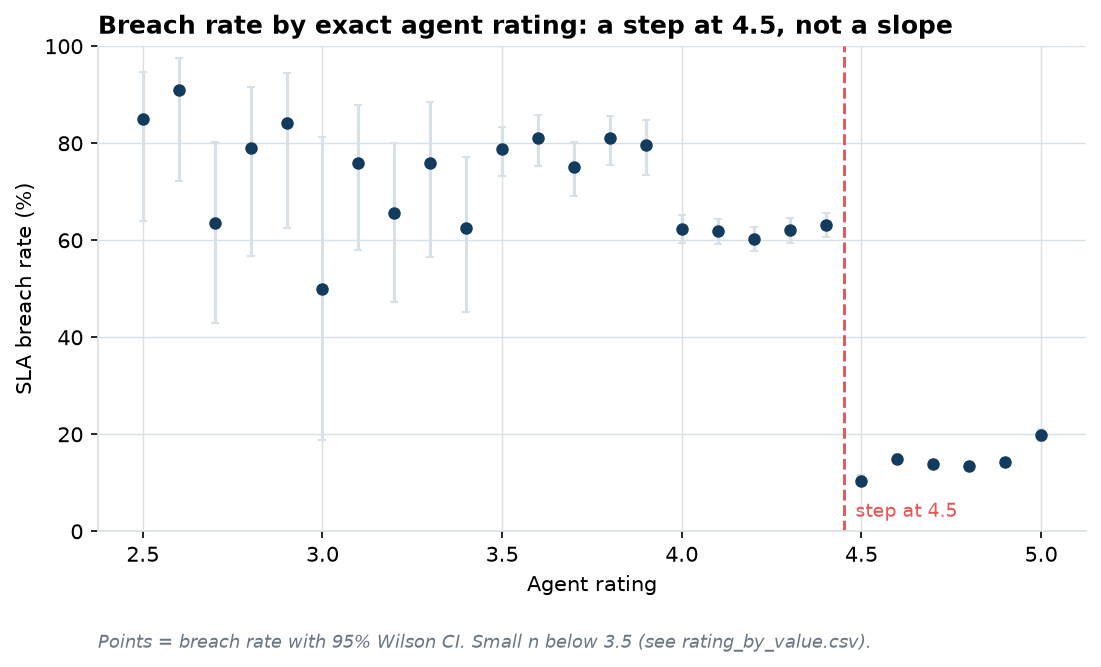

The single largest jump between two adjacent rating values is between **4.4** (63.2% breach, n=1,361) and **4.5** (10.5% breach, n=3,303): a **52.7 point** drop. Every OTHER adjacent jump in the reliable range is around **1.7 points** - this one jump is roughly 30x the size of a typical step elsewhere in the range.

In [2]:
show("rating_step.png")
import json
R = json.load(open(ROOT / "outputs" / "results.json"))
rshape = R["rating_shape"]
say(f"The single largest jump between two adjacent rating values is between **{rshape['value_below']:.1f}** "
    f"({100*rshape['rate_below']:.1f}% breach, n={rshape['n_below']:,}) and **{rshape['value_at_cut']:.1f}** "
    f"({100*rshape['rate_at_cut']:.1f}% breach, n={rshape['n_at_cut']:,}): a **{abs(rshape['step_size_pts']):.1f} point** drop. "
    f"Every OTHER adjacent jump in the reliable range is around **{rshape['typical_other_step_pts']:.1f} points** - "
    "this one jump is roughly 30x the size of a typical step elsewhere in the range.")


In [3]:
rv = tbl("rating_by_value")
lo, hi = df[df.rating_lt_4_5 == 1], df[df.rating_lt_4_5 == 0]
say(f"Splitting at 4.5: **{len(lo):,}** deliveries ({100*len(lo)/df.rating_lt_4_5.notna().sum():.1f}% of rated deliveries) have a rating below 4.5, "
    f"and they carry **{100*lo.breach_flag.sum()/df.breach_flag.sum():.1f}%** of all breaches. "
    f"Breach rate: **{100*lo.breach_flag.mean():.1f}%** (rating < 4.5) vs **{100*hi.breach_flag.mean():.1f}%** (rating >= 4.5) - "
    f"a **{100*(lo.breach_flag.mean()-hi.breach_flag.mean()):.1f} point** difference, risk ratio **{lo.breach_flag.mean()/hi.breach_flag.mean():.1f}**.")


Splitting at 4.5: **8,024** deliveries (18.4% of rated deliveries) have a rating below 4.5, and they carry **50.2%** of all breaches. Breach rate: **64.6%** (rating < 4.5) vs **14.4%** (rating >= 4.5) - a **50.2 point** difference, risk ratio **4.5**.

### Does the pattern hold up inside each traffic / area / weather combination?


In [4]:
import json
say("**Stratified by traffic x area** (Mantel-Haenszel common risk ratio, controls for both at once):")
s1 = R["rating"]["stratified_by_traffic_x_area"]
say(f"Crude risk ratio {s1['crude_risk_ratio']:.2f} -> stratified risk ratio **{s1['mh_risk_ratio']:.2f}** (95% CI {s1['mh_rr_ci_low']:.2f}-{s1['mh_rr_ci_high']:.2f}), across {s1['n_strata']} traffic x area combinations.")
say("**Stratified by traffic x weather:**")
s2 = R["rating"]["stratified_by_traffic_x_weather"]
say(f"Crude risk ratio {s2['crude_risk_ratio']:.2f} -> stratified risk ratio **{s2['mh_risk_ratio']:.2f}** (95% CI {s2['mh_rr_ci_low']:.2f}-{s2['mh_rr_ci_high']:.2f}), across {s2['n_strata']} combinations.")
display(tbl("rating_effect_by_traffic")[["traffic", "n_exposed", "rate_exposed", "n_unexposed", "rate_unexposed", "risk_ratio", "rr_ci_low", "rr_ci_high"]])


**Stratified by traffic x area** (Mantel-Haenszel common risk ratio, controls for both at once):

Crude risk ratio 4.53 -> stratified risk ratio **3.69** (95% CI 3.59-3.79), across 12 traffic x area combinations.

**Stratified by traffic x weather:**

Crude risk ratio 4.53 -> stratified risk ratio **3.62** (95% CI 3.53-3.72), across 24 combinations.

,traffic,n_exposed,rate_exposed,n_unexposed,rate_unexposed,risk_ratio,rr_ci_low,rr_ci_high
0,High,749,0.678,3529,0.124,5.477,4.953,6.057
1,Jam,3391,0.807,10193,0.292,2.767,2.674,2.864
2,Low,2203,0.320,12773,0.016,19.747,17.027,22.901
3,Medium,1619,0.724,8985,0.158,4.568,4.317,4.832


**Reading:** the risk ratio drops from the crude ~4.5 to about 3.6-3.7 once traffic and weather are held
fixed - some of the crude gap is explained by low-rated deliveries happening more in worse conditions, but a
large gap remains inside every single traffic level. **The pattern is not just a traffic or weather artefact.**

**Limitation:** rating may itself be an OUTCOME of delivery performance (a slow, late delivery may simply earn a
lower rating), or a marker of which routes/shifts get assigned to which agents. This data cannot distinguish
those explanations from "lower-rated agents perform worse." Attribute-level only - there is no individual agent
identifier, so this describes the rating attribute, never a specific agent.


## 2. Agent age: the same step pattern


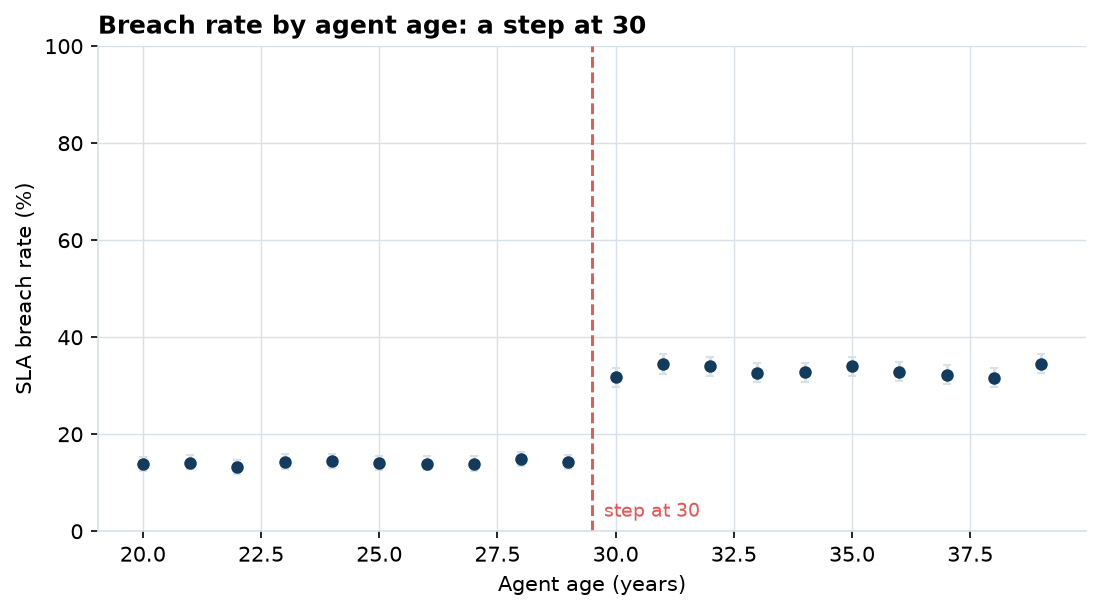

Largest adjacent jump: age **29** (14.2% breach) to age **30** (31.7% breach) - a **17.5 point** jump, versus a typical 0.6-point step elsewhere.

,group,n,breach_rate,share_of_breaches
0,"rating >= 4.5, age < 30",19171,0.090,0.168
1,"rating >= 4.5, age >= 30",16399,0.207,0.329
2,"rating < 4.5, age < 30",2437,0.539,0.127
3,"rating < 4.5, age >= 30",5587,0.693,0.375


In [5]:
show("age_step.png")
ashape = R["age_shape"]
say(f"Largest adjacent jump: age **{int(ashape['value_below'])}** ({100*ashape['rate_below']:.1f}% breach) to age "
    f"**{int(ashape['value_at_cut'])}** ({100*ashape['rate_at_cut']:.1f}% breach) - a **{ashape['step_size_pts']:.1f} point** jump, "
    f"versus a typical {ashape['typical_other_step_pts']:.1f}-point step elsewhere.")
display(tbl("rating_age_grid")[["group", "n", "breach_rate", "share_of_breaches"]])


**A change at one exact round number (30) is unusual for a real workforce** and is flagged in notebook 01 as
evidence the dataset behaves like a rule-built simulation rather than organic operational data.

**Fairness note:** age is a protected characteristic in most employment contexts. Even where a pattern like this
is genuine, it should never be used as a basis for staffing or performance decisions. The appropriate response
is to investigate data lineage and confounding factors, not to act on age directly.


## 3. Traffic and time of day: how much do they overlap?


**97.5%** of deliveries occur in an hour where that hour's most common traffic level applies; only hours [11, 15, 19, 22] contain more than one traffic level (11,958 deliveries). Jam traffic appears only in hours 19-22.

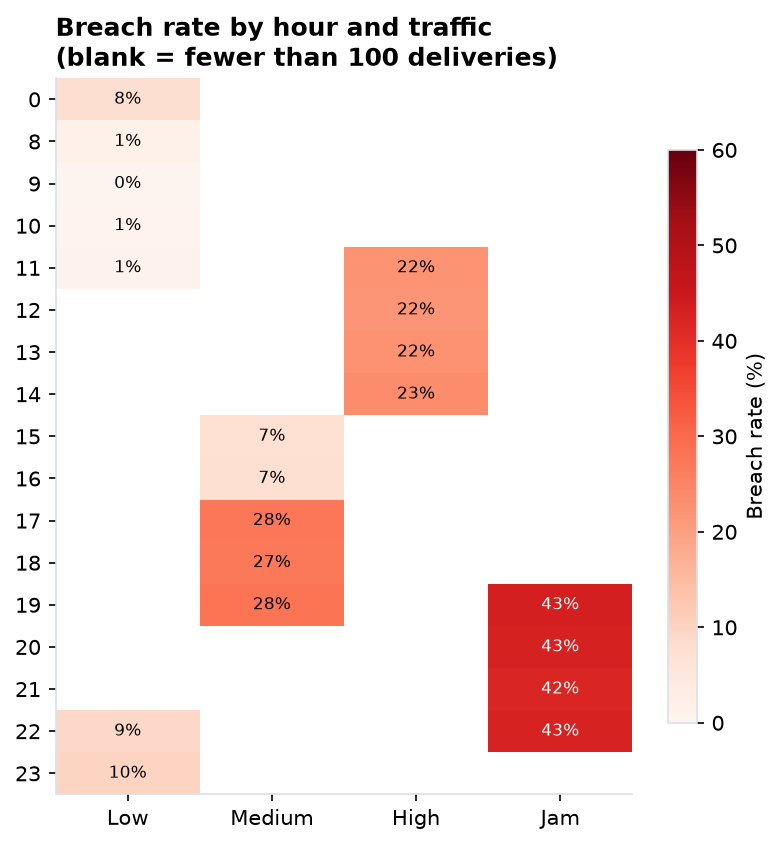

In [6]:
ident = R["traffic_hour_identifiability"]
say(f"**{100*ident['share_of_deliveries_matching_hours_modal_traffic']:.1f}%** of deliveries occur in an hour where that hour's most "
    f"common traffic level applies; only hours {ident['boundary_hours']} contain more than one traffic level "
    f"({ident['deliveries_in_boundary_hours']:,} deliveries). Jam traffic appears only in hours {ident['jam_first_hour']}-{ident['jam_last_hour']}.")
show("traffic_hour_heatmap.png")


**Contrasts that hold time of day fixed** - only possible in the few hours where more than one traffic level occurs:


In [7]:
display(tbl("within_hour_traffic_contrasts")[["order_hour", "higher_risk_traffic", "lower_risk_traffic", "n_higher", "n_lower", "rate_higher", "rate_lower", "risk_ratio", "rr_ci_low", "rr_ci_high"]])
say("**Contrasts that hold traffic fixed** - does the hour still matter within one traffic level?")
display(tbl("within_traffic_hour_contrasts"))


,order_hour,higher_risk_traffic,lower_risk_traffic,n_higher,n_lower,rate_higher,rate_lower,risk_ratio,rr_ci_low,rr_ci_high
0,11,High,Low,1758,192,0.222,0.010,21.352,5.364,84.992
1,19,Jam,Medium,4156,423,0.431,0.279,1.547,1.322,1.810
2,22,Jam,Low,402,4156,0.425,0.091,4.689,4.040,5.442


**Contrasts that hold traffic fixed** - does the hour still matter within one traffic level?

,contrast,n_first,rate_first,n_second,rate_second,risk_ratio_second_vs_first,rr_ci_low,rr_ci_high
0,Low traffic: 08-10h vs 22-23h,5724,0.009,8654,0.095,10.713,8.090,14.186
1,Medium traffic: 15-16h vs 17-19h,1491,0.073,9137,0.274,3.746,3.117,4.501


**Conclusion:** both matter. Inside the same hour, traffic level still separates breach rates; inside the same
traffic level, the evening still carries more risk than the morning. **Traffic and time of day cannot be cleanly
separated in this dataset** - they should be read together, not ranked against each other.


## 4. The traffic effect depends on the weather


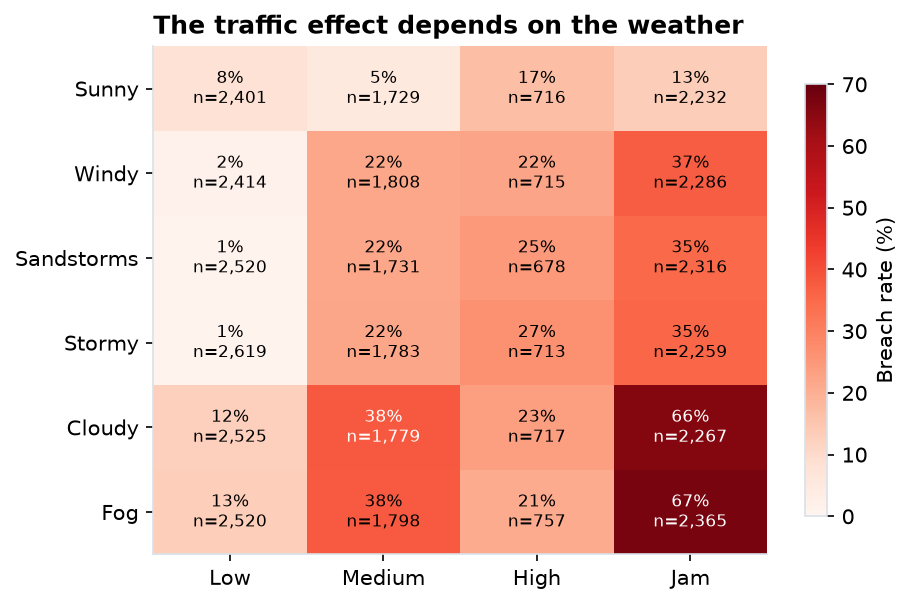

Jam traffic combined with Cloudy/Fog weather breaches far more often than Jam combined with Sunny weather. **Traffic and weather interact** - neither factor's effect is fully described in isolation.

In [8]:
show("traffic_weather_heatmap.png")
say("Jam traffic combined with Cloudy/Fog weather breaches far more often than Jam combined with Sunny weather. "
    "**Traffic and weather interact** - neither factor's effect is fully described in isolation.")


## 5. One comparable scale: risk ratio for every factor


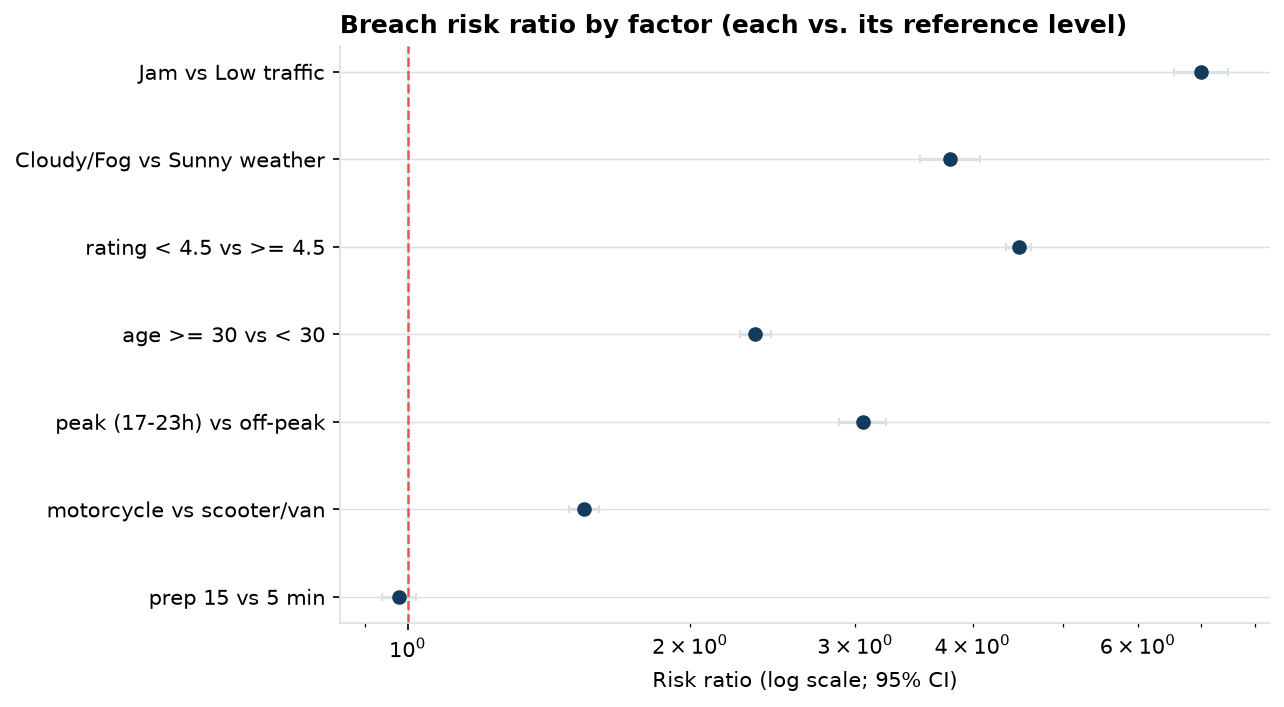

,contrast,rate_exposed,rate_reference,risk_ratio,rr_ci_low,rr_ci_high
7,Jam vs Low traffic,0.426,0.061,7.003,6.557,7.479
8,Cloudy/Fog vs Sunny weather,0.367,0.097,3.787,3.516,4.079
9,rating < 4.5 vs >= 4.5,0.646,0.144,4.479,4.346,4.615
10,age >= 30 vs < 30,0.331,0.141,2.346,2.259,2.437
11,peak (17-23h) vs off-peak,0.291,0.095,3.054,2.884,3.235
12,motorcycle vs scooter/van,0.277,0.180,1.542,1.486,1.600
13,prep 15 vs 5 min,0.233,0.238,0.979,0.940,1.021


Every factor above is compared the same way: exposed-group breach rate versus reference-group breach rate, as a plain risk ratio with a 95% CI. This puts rating, traffic, weather, age, vehicle and prep time on one scale without needing to compare unlike statistics.

In [9]:
show("risk_ratios_by_factor.png")
drv = tbl("sla_sensitivity_driver_risk_ratios")
display(drv[drv.percentile == 0.75][["contrast", "rate_exposed", "rate_reference", "risk_ratio", "rr_ci_low", "rr_ci_high"]])
say("Every factor above is compared the same way: exposed-group breach rate versus reference-group breach rate, as a plain risk ratio with a 95% CI. "
    "This puts rating, traffic, weather, age, vehicle and prep time on one scale without needing to compare unlike statistics.")


### Summary
* **Rating < 4.5** and **Jam traffic** show the largest risk ratios of any single factor tested.
* **Weather (Cloudy/Fog)** and **evening peak hours** are next.
* **Age >= 30** and **motorcycle** show a smaller but still real association.
* **Preparation time shows no association** (risk ratio close to 1).
* Ranking "the strongest factor" is not meaningful on its own: traffic, time of day and weather overlap and interact, so any single ranking depends on which factors are held fixed.
